# 0307 — EDA: Optimal Stopping Playbook

Applies optimal-stopping theory to the driver's live ride-offer stream: given a sequential flow of transient offers, when is the rational moment to accept vs. keep searching? Builds a behavioral clock (search rhythm, sanitized for trip-completion resets), computes the "continuation value" of waiting for a better offer under different market regimes, and generalizes it into an efficient frontier of rational search time by target earnings.

```mermaid
flowchart TD
    A["pienza.db: offers + engineered_features"] --> B["Phase 1\nData foundation: quality index,\ninter-offer delta, sanitized search rhythm"]
    B --> C["Phase 2\nBaseline escape clock:\nindifference point, baseline vs target EPH"]
    B --> D["Phase 3\nOpportunity oracle:\nglobal probabilities, quadrant matrix,\nCV simulator, CV playbook"]
    C --> E["Phase 4\nEfficient frontier:\nrational search time by target EPH"]
    D --> E
    B --> F["Phase 5\nSupply elasticity:\nacceptance rate vs. offer quality"]

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```


## Phase 1 — Data foundation

Builds the core offer dataset with a normalized quality index, computes the time between consecutive offers, characterizes each session's typical rhythm, and sanitizes the search clock so trip-completion resets don't get counted as search time.

#### 1.1 — Database connection & visual canon

In [16]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, clear_output, display
from scipy.interpolate import interp1d
from sqlalchemy import create_engine

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# --- Database connection ---
DB_PATH = '/workspaces/pienza/data/pienza.db'

if not os.path.exists(DB_PATH):
    print(f"ERROR: database not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"SQL engine active: {DB_PATH}")

# --- Pienza visual canon ---
PIENZA_PURPLE = '#440154'
PIENZA_TEAL = '#21918c'
PIENZA_GREY = '#FAFAFA'
PIENZA_TEXT = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_GREY, 'axes.facecolor': PIENZA_GREY, 'text.color': PIENZA_TEXT,
    'xtick.color': '#333333', 'ytick.color': '#333333', 'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0', 'font.family': 'sans-serif',
    'axes.titlecolor': PIENZA_PURPLE, 'axes.titleweight': 'bold',
    'figure.titlesize': 24, 'figure.titleweight': 'bold'
})

print("Visual identity loaded.")


SQL engine active: /workspaces/pienza/data/pienza.db
Visual identity loaded.


#### 1.2 — Ingest & basic feature engineering

Loads the offer dataset (fare, timing, product category, operational EPH) and computes a per-category-normalized `offer_quality_index`: an offer's EPH relative to the median EPH for its product tier.

In [17]:
if 'db_engine' in locals():
    print("--- Ingesting and preparing the offer dataset ---")

    # 1. Unified query (includes columns needed by later cells)
    query_campaign = """
    SELECT
        o.offer_id,
        o.session_fk,
        o.upfront_fare,
        o.est_trip_time_sec,
        o.time_to_pickup_sec,
        o.offer_timestamp,
        oa.offer_action_description as offer_action,
        pc.category_name as product_category,
        ef.eph_operational as eph_real
    FROM offers o
    LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    LEFT JOIN offer_action oa ON o.offer_action_fk = oa.offer_action_id
    WHERE ef.eph_operational IS NOT NULL
    """

    try:
        df_campaign = pd.read_sql_query(query_campaign, db_engine)
        print(f"Ingest complete: {len(df_campaign)} offers loaded.")

        # 2. Basic feature engineering
        df_campaign['offer_timestamp'] = pd.to_datetime(df_campaign['offer_timestamp'])

        def simplify_category(cat):
            if pd.isna(cat):
                return 'Other'
            cat = cat.lower()
            if 'uberx' in cat:
                return 'UberX'
            elif 'comfort' in cat or 'business' in cat:
                return 'Mid-Tier'
            elif 'black' in cat:
                return 'Black'
            return 'Other'

        df_campaign['simplified_category'] = df_campaign['product_category'].apply(simplify_category)
        df_campaign = df_campaign[df_campaign['simplified_category'].isin(['UberX', 'Mid-Tier', 'Black'])].copy()

        # 3. Normalization: quality index relative to each product tier's median EPH
        global_anchors = df_campaign.groupby('simplified_category')['eph_real'].median().to_dict()
        df_campaign['offer_quality_index'] = df_campaign.apply(lambda row: row['eph_real'] / global_anchors.get(row['simplified_category'], 1), axis=1)

        # 4. Level/state definition (kept for downstream cells that still reference it)
        df_campaign['is_success'] = (df_campaign['offer_quality_index'] >= 1.0).astype(int)

        print("\nDataset ready.")

    except Exception as e:
        print(f"ERROR during ingest: {e}")


--- Ingesting and preparing the offer dataset ---
Ingest complete: 4750 offers loaded.

Dataset ready.


#### 1.3 — Inter-offer delta

Computes the elapsed time between consecutive offers within each session, as the raw input for characterizing market rhythm.

--- Calculating time between offers (delta) ---
Typical wait time (median): 22.00 seconds
Average wait time (mean):   125.45 seconds


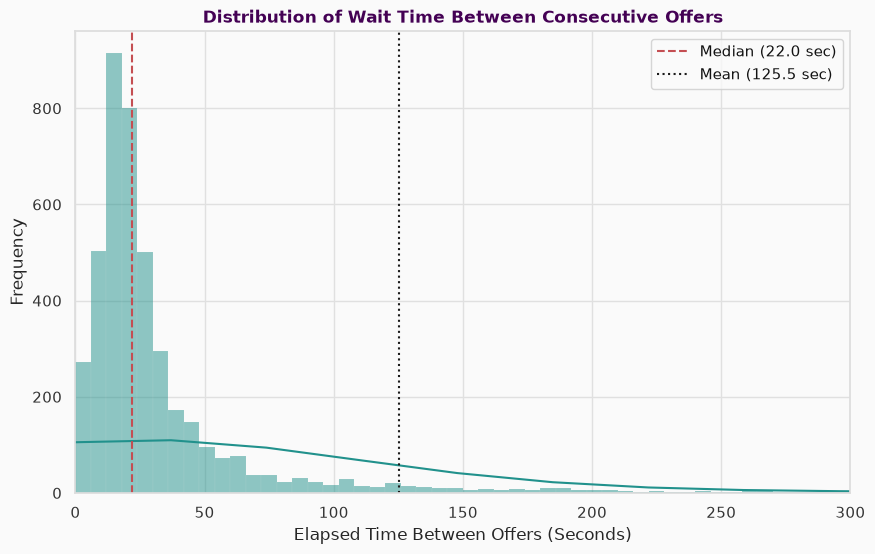

In [18]:
if 'df_campaign' in locals() and not df_campaign.empty:

    print("--- Calculating time between offers (delta) ---")

    # Ensure data is sorted chronologically within each session
    df_campaign.sort_values(by=['session_fk', 'offer_timestamp'], inplace=True)

    # 1. Compute the delta
    df_campaign['previous_timestamp'] = df_campaign.groupby('session_fk')['offer_timestamp'].shift(1)
    df_campaign['delta_time'] = (df_campaign['offer_timestamp'] - df_campaign['previous_timestamp']).dt.total_seconds()

    # The first offer of each session has NaN delta_time; ignore for threshold calc
    df_deltas = df_campaign.dropna(subset=['delta_time'])

    # 2. Statistical analysis of the delta
    global_median_delta = df_deltas['delta_time'].median()
    global_mean_delta = df_deltas['delta_time'].mean()

    print(f"Typical wait time (median): {global_median_delta:.2f} seconds")
    print(f"Average wait time (mean):   {global_mean_delta:.2f} seconds")

    # 3. Visualize the distribution
    plt.figure(figsize=(10, 6))
    # Cap bins so extreme outliers don't distort the plot
    sns.histplot(df_deltas['delta_time'], bins=50, kde=True, color=PIENZA_TEAL, binrange=(0, 300))
    plt.xlim(0, 300)
    plt.axvline(x=global_median_delta, color='r', linestyle='--', label=f'Median ({global_median_delta:.1f} sec)')
    plt.axvline(x=global_mean_delta, color='k', linestyle=':', label=f'Mean ({global_mean_delta:.1f} sec)')
    plt.title('Distribution of Wait Time Between Consecutive Offers', color=PIENZA_PURPLE)
    plt.xlabel('Elapsed Time Between Offers (Seconds)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    # Store the metric (0 for each session's first offer)
    df_campaign['delta_time_sec'] = df_campaign['delta_time'].fillna(0)

    # Hand off to the next cell
    global df_opportunity_cost
    df_opportunity_cost = df_campaign

else:
    print("Run cell 1.2 first to load df_campaign.")


#### 1.4 — Session rhythm distribution

Computes each session's median inter-offer delta, then the global quartiles of those session rhythms — candidate thresholds for a Hot/Cold market classification.

--- Session rhythm analysis ---
P25 (fast rhythm):  20.00 seconds between offers (suggested Hot threshold)
P50 (typical rhythm): 22.00 seconds between offers
P75 (slow rhythm):  26.00 seconds between offers (suggested Cold threshold)


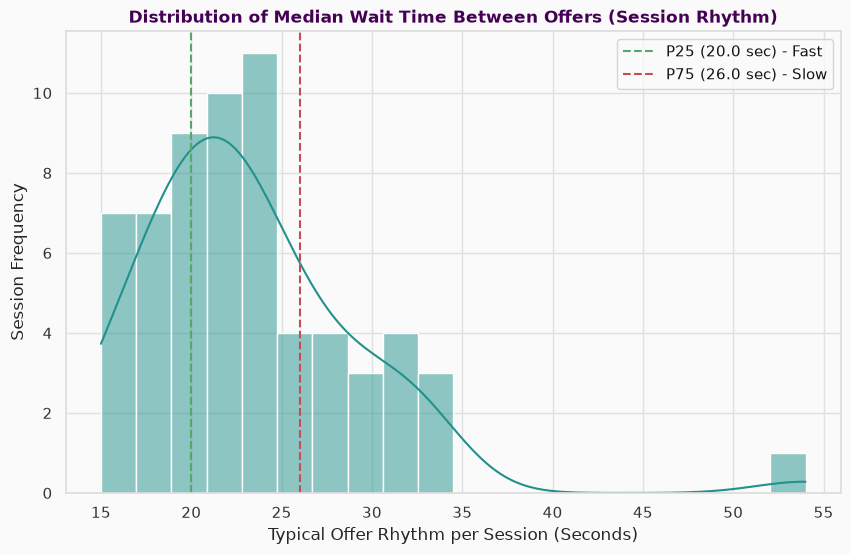

In [19]:
if 'df_opportunity_cost' in locals():

    # Only use valid deltas (not the initial 0)
    df_deltas_valid = df_opportunity_cost[df_opportunity_cost['delta_time_sec'] > 0].copy()

    # 1. Typical rhythm (median) per session
    session_median_deltas = df_deltas_valid.groupby('session_fk')['delta_time_sec'].median().reset_index()
    session_median_deltas.columns = ['session_fk', 'session_median_delta_sec']

    # 2. Global quartiles of these session rhythms
    Q25 = session_median_deltas['session_median_delta_sec'].quantile(0.25)
    Q50 = session_median_deltas['session_median_delta_sec'].quantile(0.50)  # median of medians
    Q75 = session_median_deltas['session_median_delta_sec'].quantile(0.75)

    print("--- Session rhythm analysis ---")
    print(f"P25 (fast rhythm):  {Q25:.2f} seconds between offers (suggested Hot threshold)")
    print(f"P50 (typical rhythm): {Q50:.2f} seconds between offers")
    print(f"P75 (slow rhythm):  {Q75:.2f} seconds between offers (suggested Cold threshold)")

    # 3. Visualize the distribution of session rhythms
    plt.figure(figsize=(10, 6))
    sns.histplot(session_median_deltas['session_median_delta_sec'], bins=20, kde=True, color=PIENZA_TEAL)

    plt.axvline(x=Q25, color='g', linestyle='--', label=f'P25 ({Q25:.1f} sec) - Fast')
    plt.axvline(x=Q75, color='r', linestyle='--', label=f'P75 ({Q75:.1f} sec) - Slow')

    plt.title('Distribution of Median Wait Time Between Offers (Session Rhythm)', color=PIENZA_PURPLE)
    plt.xlabel('Typical Offer Rhythm per Session (Seconds)')
    plt.ylabel('Session Frequency')
    plt.legend()
    plt.show()

    # Merge the session rhythm back for classification
    df_opportunity_cost = pd.merge(df_opportunity_cost, session_median_deltas, on='session_fk', how='left')

else:
    print("Run cells 1.2 and 1.3 first.")


#### 1.5 — Session rhythm volatility (full inspection)

Computes P25/P50/P75 of `delta_time_sec` for every session and displays the full table, to inform filtering decisions.

In [20]:
if 'df_opportunity_cost' in locals():
    print("--- Calculating per-session offer rhythm volatility (quartiles) ---")

    # Only use valid deltas (not the initial 0)
    df_deltas_valid = df_opportunity_cost[df_opportunity_cost['delta_time_sec'] > 0].copy()

    # 1. Quartile function
    def calculate_session_quantiles(group):
        q = group['delta_time_sec'].quantile([0.25, 0.5, 0.75])

        return pd.Series({
            'rhythm_P25_sec': q[0.25],
            'rhythm_P50_median_sec': q[0.5],
            'rhythm_P75_sec': q[0.75]
        })

    # 2. Apply to all sessions
    df_session_metrics = df_deltas_valid.groupby('session_fk').apply(calculate_session_quantiles).reset_index()

    # 3. Merge metrics back into the main dataframe (useful for future filters)
    df_opportunity_cost = pd.merge(df_opportunity_cost, df_session_metrics, on='session_fk', how='left')

    # 4. Print the full table for inspection
    print(f"Offer rhythm quartiles calculated for {len(df_session_metrics)} sessions.")

    pd.set_option('display.max_rows', None)

    display_cols = ['session_fk', 'rhythm_P25_sec', 'rhythm_P50_median_sec', 'rhythm_P75_sec']

    print("\n--- Per-session volatility: quartile table (seconds) ---")
    display(df_session_metrics[display_cols].style.format({
        'rhythm_P25_sec': '{:.1f}s',
        'rhythm_P50_median_sec': '{:.1f}s',
        'rhythm_P75_sec': '{:.1f}s'
    }))

    pd.set_option('display.max_rows', 10)

else:
    print("Run previous cells first.")


--- Calculating per-session offer rhythm volatility (quartiles) ---
Offer rhythm quartiles calculated for 63 sessions.

--- Per-session volatility: quartile table (seconds) ---


,session_fk,rhythm_P25_sec,rhythm_P50_median_sec,rhythm_P75_sec
0,SID0001,17.0s,27.0s,43.0s
1,SID0002,12.0s,16.0s,22.0s
2,SID0003,16.2s,26.0s,67.5s
3,SID0004,16.0s,21.0s,48.8s
4,SID0005-1,14.0s,20.0s,26.0s
5,SID0005-2,14.0s,20.0s,28.0s
6,SID0006,17.2s,33.0s,206.5s
7,SID0007,15.0s,23.0s,45.5s
8,SID0008,14.0s,21.0s,30.0s
9,SID0009,21.0s,27.0s,108.8s


#### 1.6 — Search stream sanitization (the behavioral clock)

Isolates search time from trip time by resetting the clock to 0s immediately following an ACCEPTED offer — otherwise the delta after a completed trip would be miscounted as search patience.

In [21]:
if 'db_engine' in locals():
    print("--- 1.6: Sanitizing search stream (reset logic) ---")

    # 1. Fetch action labels
    query_actions = """
    SELECT
        o.offer_id,
        oa.offer_action_description as offer_action
    FROM offers o
    LEFT JOIN offer_action oa ON o.offer_action_fk = oa.offer_action_id
    """
    df_actions = pd.read_sql_query(query_actions, db_engine)

    # 2. Merge into the main dataframe
    if 'offer_action' in df_opportunity_cost.columns:
        df_opportunity_cost.drop(columns=['offer_action'], inplace=True)

    df_opportunity_cost = pd.merge(df_opportunity_cost, df_actions, on='offer_id', how='left')

    # 3. Chronological sorting
    df_opportunity_cost.sort_values(by=['session_fk', 'offer_timestamp'], inplace=True)

    # 4. Track previous action
    df_opportunity_cost['prev_action'] = df_opportunity_cost.groupby('session_fk')['offer_action'].shift(1)

    # 5. Apply the reset logic
    def sanitize_search_time(row):
        if pd.isna(row['prev_action']):
            return np.nan  # Session start

        # If the driver accepted the previous trip, search time for this
        # new offer effectively starts at 0.0s (trip completion reset).
        if 'ACCEPTED' in str(row['prev_action']).upper():
            return 0.0

        # Otherwise the driver was already available, so the delta
        # from cell 1.3 (delta_time_sec) is the true search wait.
        return row['delta_time_sec']

    df_opportunity_cost['sanitized_search_delta'] = df_opportunity_cost.apply(sanitize_search_time, axis=1)

    # 6. Generate the purified session list
    df_valid_stream = df_opportunity_cost.dropna(subset=['sanitized_search_delta'])

    df_sanitized_metrics = df_valid_stream.groupby('session_fk')['sanitized_search_delta'].agg([
        ('Search_P25', lambda x: x.quantile(0.25)),
        ('Search_P50_Median', 'median'),
        ('Search_P75', lambda x: x.quantile(0.75))
    ]).reset_index()

    # 7. Display full list
    print(f"Sanitization complete: {len(df_sanitized_metrics)} sessions.")
    pd.set_option('display.max_rows', None)
    print("\n--- Sanitized search rhythm by session (seconds) ---")
    display(df_sanitized_metrics.style.format({
        'Search_P25': '{0:.1f}s',
        'Search_P50_Median': '{0:.1f}s',
        'Search_P75': '{0:.1f}s'
    }))
    pd.set_option('display.max_rows', 10)

else:
    print("DB engine not active.")


--- 1.6: Sanitizing search stream (reset logic) ---
Sanitization complete: 63 sessions.

--- Sanitized search rhythm by session (seconds) ---


,session_fk,Search_P25,Search_P50_Median,Search_P75
0,SID0001,17.0s,25.0s,37.0s
1,SID0002,12.0s,16.0s,22.0s
2,SID0003,16.0s,23.5s,58.8s
3,SID0004,15.0s,20.0s,32.5s
4,SID0005-1,14.0s,20.0s,26.0s
5,SID0005-2,12.0s,18.0s,25.0s
6,SID0006,6.8s,20.0s,43.5s
7,SID0007,14.5s,21.0s,38.5s
8,SID0008,14.0s,20.0s,28.0s
9,SID0009,20.0s,26.0s,41.0s


## Phase 2 — Baseline escape clock

For a driver holding a baseline-quality offer ($150/hr), how long is it rational to keep searching for a better one ($200/hr) before the wait itself erodes the gain?

#### 2.1 — Baseline escape clock (indifference point)

For each session, builds a baseline and a target archetype from nearby real offers, then algebraically solves for the maximum search time at which switching to the target still beats taking the baseline now.

--- 2.1: Calculating the baseline escape clock (150 vs 200) ---
Global escape clock (mean): 11.44 minutes
Average decision volume:    35.4 offers


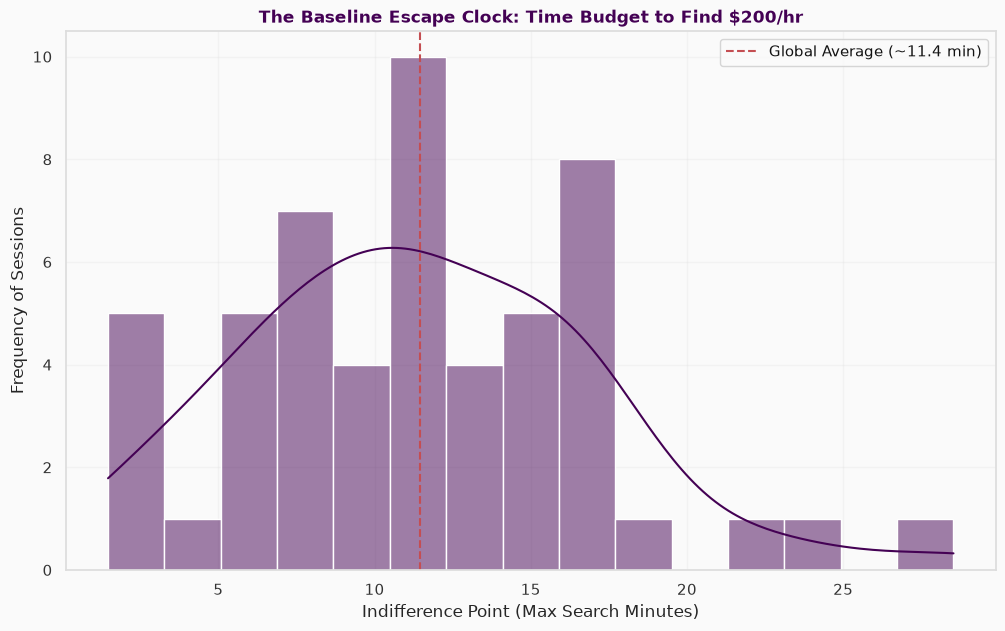


--- Top 10 sessions by decision volume (patience potential) ---


,session_id,escape_clock_min,decision_volume,session_rhythm_sec
28,SID0032,28.5 min,114 offers,15.0s
24,SID0028,16.7 min,67 offers,15.0s
1,SID0002,17.1 min,64 offers,16.0s
27,SID0031,17.3 min,61 offers,17.0s
45,SID0054,21.5 min,56 offers,23.0s
41,SID0049,13.8 min,55 offers,15.0s
39,SID0047,14.4 min,54 offers,16.0s
21,SID0025,17.8 min,53 offers,20.0s
40,SID0048,16.6 min,52 offers,19.0s
9,SID0011,23.2 min,52 offers,27.0s


In [22]:
if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 2.1: Calculating the baseline escape clock (150 vs 200) ---")

    # 1. Threshold definitions
    EPH_BASELINE = 150.0
    EPH_TARGET = 200.0

    # We use the median search rhythm computed in cell 1.6 for context
    # (assuming rhythm_P50_median_sec exists from the earlier merge)

    escape_points = []

    # 2. Iterate by session (unified market approach)
    for session_id, df_session in df_opportunity_cost.groupby('session_fk'):

        # 2.1. Build archetypes for this session
        props_baseline = df_session[
            df_session['eph_real'].between(EPH_BASELINE - 15, EPH_BASELINE + 15)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        props_target = df_session[
            df_session['eph_real'].between(EPH_TARGET - 15, EPH_TARGET + 15)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        # Skip sessions without enough variety to form both archetypes
        if props_baseline.isnull().any() or props_target.isnull().any():
            continue

        # 2.2. Baseline EPH (the "bird in hand")
        eph_baseline_immediate = (props_baseline['upfront_fare'] /
                                  (props_baseline['time_to_pickup_sec'] + props_baseline['est_trip_time_sec'])) * 3600

        # 2.3. Algebraic indifference point
        if eph_baseline_immediate > 0:
            # Formula: (fare_target * 3600 / eph_baseline) - total_time_target
            t_max_sec = ((props_target['upfront_fare'] * 3600) / eph_baseline_immediate) - \
                        (props_target['time_to_pickup_sec'] + props_target['est_trip_time_sec'])

            t_max_min = t_max_sec / 60.0

            if t_max_min > 0:
                # "Decision volume": how many offers fit in this search window?
                session_rhythm = df_session['sanitized_search_delta'].median()
                decision_volume = (t_max_sec / session_rhythm) if session_rhythm > 0 else np.nan

                escape_points.append({
                    'session_id': session_id,
                    'escape_clock_min': t_max_min,
                    'decision_volume': decision_volume,
                    'session_rhythm_sec': session_rhythm
                })

    df_escape = pd.DataFrame(escape_points)

    # 3. Analysis & visualization
    if not df_escape.empty:
        avg_clock = df_escape['escape_clock_min'].mean()
        avg_volume = df_escape['decision_volume'].mean()

        print(f"Global escape clock (mean): {avg_clock:.2f} minutes")
        print(f"Average decision volume:    {avg_volume:.1f} offers")

        plt.figure(figsize=(12, 7))
        sns.histplot(df_escape['escape_clock_min'], bins=15, kde=True, color=PIENZA_PURPLE)

        plt.axvline(x=avg_clock, color='r', linestyle='--',
                    label=f'Global Average (~{avg_clock:.1f} min)')

        plt.title('The Baseline Escape Clock: Time Budget to Find $200/hr', color=PIENZA_PURPLE)
        plt.xlabel('Indifference Point (Max Search Minutes)')
        plt.ylabel('Frequency of Sessions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Summary table for the "decision volume" insight
        print("\n--- Top 10 sessions by decision volume (patience potential) ---")
        display(df_escape.sort_values('decision_volume', ascending=False).head(10).style.format({
            'escape_clock_min': '{:.1f} min',
            'decision_volume': '{:.0f} offers',
            'session_rhythm_sec': '{:.1f}s'
        }))

    else:
        print("Not enough data to calculate escape points. Check EPH ranges.")

else:
    print("Dataframe df_opportunity_cost not found.")


## Phase 3 — Opportunity oracle

How likely is a driver to find a baseline or target-quality offer within a given search window, and does waiting for one pay off once the continuation value is computed?

#### 3.1 — Global oracle: success probabilities (150 vs 200)

Computes the empirical, tier-agnostic probability of finding a baseline-quality (>=$150) or target-quality (>=$200) offer within two candidate search windows.

In [23]:
if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 3.1: Auditing the global future (tier-agnostic: 150 vs 200) ---")

    # 1. Prepare dataset (sorted by time)
    df_prob = df_opportunity_cost.sort_values('offer_timestamp').copy()

    # 2. Define global success flags
    # 150 = baseline / "better than nothing"
    # 200 = target / "the goal"
    df_prob['is_baseline_target'] = (df_prob['eph_real'] >= 150).astype(int)
    df_prob['is_target_reached'] = (df_prob['eph_real'] >= 200).astype(int)

    # 3. Set time windows (discovered in Phase 2)
    # 210s = 3.5m (the tight gem-hunting budget)
    # 684s = 11.4m (the generous baseline-escape budget)
    windows = {
        'Gem Budget (3.5m)': '210s',
        'Escape Budget (11.4m)': '684s'
    }

    # 4. Vectorized look-ahead
    df_prob = df_prob.set_index('offer_timestamp')
    df_reversed = df_prob.iloc[::-1]  # Reverse to look "forward" using rolling

    oracle_results = []

    for label, window_size in windows.items():
        # Probability of finding at least one baseline offer (>= 150)
        found_baseline = df_reversed['is_baseline_target'].rolling(window=window_size).max().iloc[::-1]

        # Probability of finding at least one target offer (>= 200)
        found_target = df_reversed['is_target_reached'].rolling(window=window_size).max().iloc[::-1]

        oracle_results.append({
            'Window': label,
            'Prob. of Baseline (>$150)': found_baseline.mean(),
            'Prob. of Target (>$200)': found_target.mean()
        })

    # 5. Presentation
    df_final_oracle = pd.DataFrame(oracle_results)

    print("\n## The Global Oracle: Success Probabilities (150 vs 200)")
    display(df_final_oracle.style.format({
        'Prob. of Baseline (>$150)': '{:.1%}',
        'Prob. of Target (>$200)': '{:.1%}'
    }).background_gradient(cmap='Purples'))

else:
    print("Error: df_opportunity_cost not loaded.")


--- 3.1: Auditing the global future (tier-agnostic: 150 vs 200) ---

## The Global Oracle: Success Probabilities (150 vs 200)


,Window,Prob. of Baseline (>$150),Prob. of Target (>$200)
0,Gem Budget (3.5m),99.3%,85.7%
1,Escape Budget (11.4m),99.6%,92.0%


#### 3.2 — Strategic probability matrix

Splits sessions into quadrants by quality (Rich/Poor) and velocity (Fast/Slow), then computes the probability of finding a "super gem" offer (quality index >= 1.5) within each quadrant across several time horizons.

--- 3.2: Constructing the strategic heatmap ---
Auditing future possibilities across quadrants...


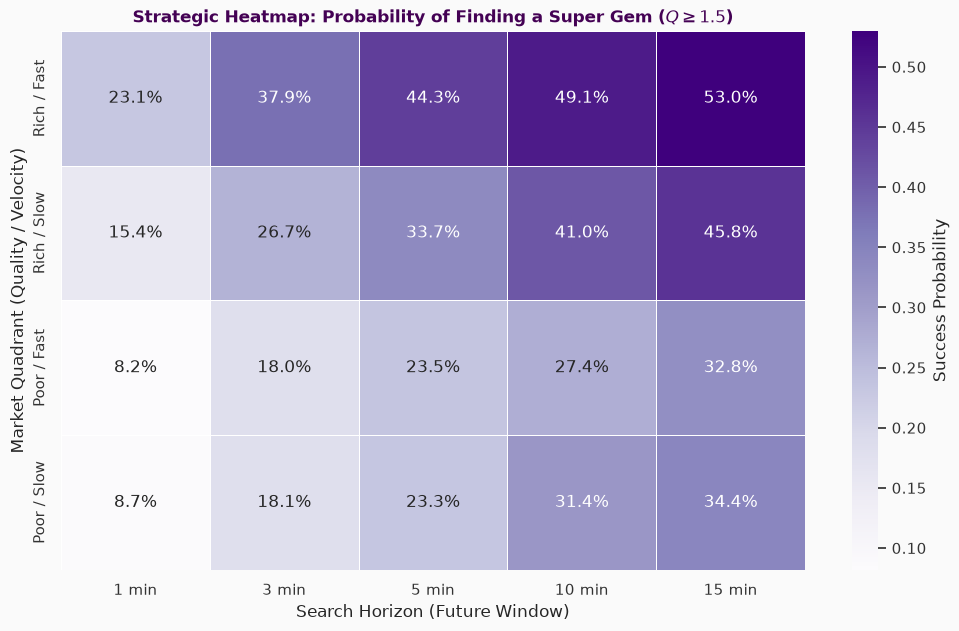


## Strategic Probability Matrix


Window,1 min,3 min,5 min,10 min,15 min
Quadrant,,,,,
Rich / Fast,23.1%,37.9%,44.3%,49.1%,53.0%
Rich / Slow,15.4%,26.7%,33.7%,41.0%,45.8%
Poor / Fast,8.2%,18.0%,23.5%,27.4%,32.8%
Poor / Slow,8.7%,18.1%,23.3%,31.4%,34.4%


In [24]:
if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 3.2: Constructing the strategic heatmap ---")

    # 1. Axis 1: quality (Rich vs. Poor)
    session_mqi = df_opportunity_cost.groupby('session_fk')['offer_quality_index'].mean().to_dict()
    df_opportunity_cost['session_mqi'] = df_opportunity_cost['session_fk'].map(session_mqi)
    df_opportunity_cost['quality_state'] = df_opportunity_cost['session_mqi'].apply(
        lambda x: 'Rich' if x >= 1.0 else 'Poor'
    )

    # 2. Axis 2: velocity (Fast vs. Slow)
    global_median_rhythm = df_opportunity_cost['sanitized_search_delta'].median()
    session_rhythm = df_opportunity_cost.groupby('session_fk')['sanitized_search_delta'].median().to_dict()
    df_opportunity_cost['session_rhythm'] = df_opportunity_cost['session_fk'].map(session_rhythm)

    df_opportunity_cost['velocity_state'] = df_opportunity_cost['session_rhythm'].apply(
        lambda x: 'Fast' if x <= global_median_rhythm else 'Slow'
    )

    # 3. Build the strategic quadrant
    df_opportunity_cost['quadrant'] = df_opportunity_cost['quality_state'] + ' / ' + df_opportunity_cost['velocity_state']

    # 4. Vectorized probability audit
    df_prob = df_opportunity_cost.sort_values('offer_timestamp').copy()
    df_prob['is_super_gem'] = (df_prob['offer_quality_index'] >= 1.5).astype(int)
    df_prob = df_prob.set_index('offer_timestamp')
    df_reversed = df_prob.iloc[::-1]

    time_windows = {
        '1 min': '60s',
        '3 min': '180s',
        '5 min': '300s',
        '10 min': '600s',
        '15 min': '900s'
    }

    print("Auditing future possibilities across quadrants...")

    quadrant_probs = []
    for label, delta in time_windows.items():
        # Rolling window looking forward
        found_gem = df_reversed['is_super_gem'].rolling(window=delta).max().iloc[::-1]

        # Group by quadrant and compute success rate
        probs = found_gem.groupby(df_prob['quadrant']).mean()
        for quad, p in probs.items():
            quadrant_probs.append({'Quadrant': quad, 'Window': label, 'Probability': p})

    # 5. Matrix generation
    prob_matrix = pd.DataFrame(quadrant_probs).pivot(index='Quadrant', columns='Window', values='Probability')

    ordered_idx = ['Rich / Fast', 'Rich / Slow', 'Poor / Fast', 'Poor / Slow']
    prob_matrix = prob_matrix.reindex([i for i in ordered_idx if i in prob_matrix.index])
    prob_matrix = prob_matrix[['1 min', '3 min', '5 min', '10 min', '15 min']]

    # 6. Visualization
    plt.figure(figsize=(12, 7))
    sns.heatmap(prob_matrix, annot=True, fmt=".1%", cmap="Purples", linewidths=.5, cbar_kws={'label': 'Success Probability'})

    plt.title(r'Strategic Heatmap: Probability of Finding a Super Gem ($Q \geq 1.5$)', color=PIENZA_PURPLE)
    plt.xlabel('Search Horizon (Future Window)')
    plt.ylabel('Market Quadrant (Quality / Velocity)')
    plt.show()

    print("\n## Strategic Probability Matrix")
    display(prob_matrix.style.format('{:.1%}')
                             .background_gradient(cmap='Purples', axis=None))

else:
    print("Dataframe df_opportunity_cost not found.")


#### 3.3 — Continuation value simulator (interactive)

Defines `simulate_strategy(target_eph)`: builds baseline/target archetypes, runs the vectorized oracle, and computes the Continuation Value (CV) of waiting vs. taking the baseline immediately, across quadrants and time windows. Runs once here for a $230/hr target.

--- Pienza Strategy Simulator ---
Analyzing scenarios for target EPH: $230/hr

## Oracle: Probability of Finding >= $230/hr


window,1m,3m,5m,10m,15m
quadrant,,,,,
Rich / Fast,66.6%,80.4%,84.3%,88.3%,89.6%
Rich / Slow,54.9%,70.6%,76.4%,81.1%,82.0%
Poor / Fast,32.6%,52.1%,59.7%,67.4%,70.6%
Poor / Slow,27.7%,48.1%,59.7%,73.6%,75.4%



## Playbook: Continuation Value (CV) of Waiting for $230/hr


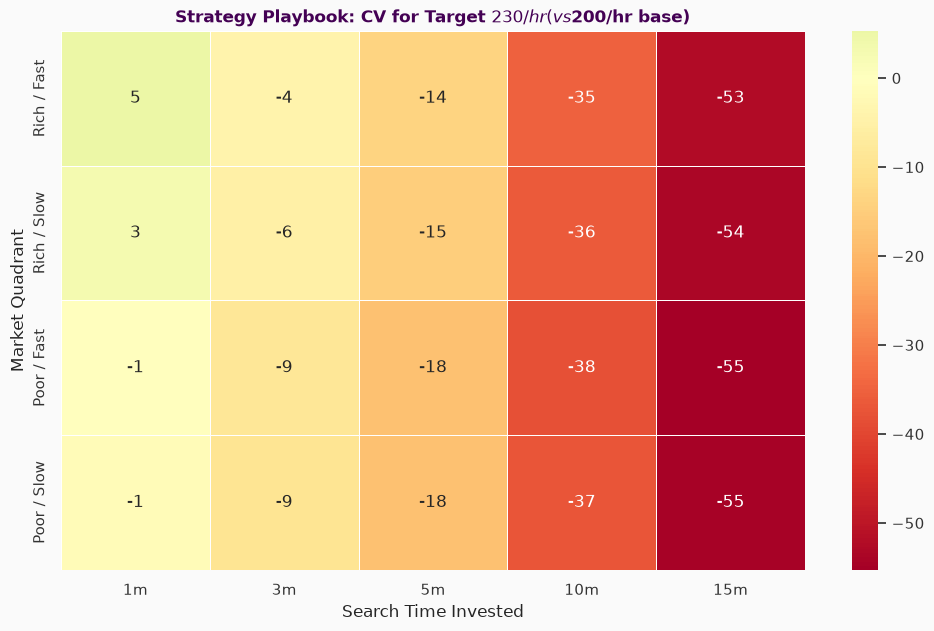

In [25]:
if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    def simulate_strategy(target_eph):
        clear_output(wait=True)
        print("--- Pienza Strategy Simulator ---")
        print(f"Analyzing scenarios for target EPH: ${target_eph}/hr\n")

        # 1. Archetype construction
        # Baseline (what you have now): target - $30 (e.g. if target is 230, baseline is 200)
        baseline_eph = target_eph - 30

        props_base = df_opportunity_cost[df_opportunity_cost['eph_real'].between(baseline_eph - 15, baseline_eph + 15)][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()
        props_target = df_opportunity_cost[df_opportunity_cost['eph_real'].between(target_eph - 15, target_eph + 15)][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        if props_base.isnull().any() or props_target.isnull().any():
            print(f"Data scarcity for archetype ${target_eph}. Try a value between 150 and 280.")
            return

        # 2. Vectorized oracle (probability of finding target_eph)
        df_sim = df_opportunity_cost.sort_values('offer_timestamp').copy()
        df_sim['is_success'] = (df_sim['eph_real'] >= target_eph).astype(int)
        df_sim = df_sim.set_index('offer_timestamp')
        df_reversed = df_sim.iloc[::-1]

        time_windows = {'1m': '60s', '3m': '180s', '5m': '300s', '10m': '600s', '15m': '900s'}

        # Audit futures
        prob_results = []
        for label, delta in time_windows.items():
            found_success = df_reversed['is_success'].rolling(window=delta).max().iloc[::-1]
            probs = found_success.groupby(df_sim['quadrant']).mean()
            for quad, p in probs.items():
                prob_results.append({'quadrant': quad, 'window': label, 'prob': p, 'window_sec': int(delta[:-1])})

        res_df = pd.DataFrame(prob_results)

        # 3. Synthesis: Continuation Value (CV)
        # Constant baseline EPH (immediate acceptance)
        eph_base_immediate = (props_base['upfront_fare'] / (props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec'])) * 3600

        def calculate_cv(row):
            # Scenario A: success (you find the target)
            cycle_success = row['window_sec'] + props_target['time_to_pickup_sec'] + props_target['est_trip_time_sec']
            eph_success = (props_target['upfront_fare'] / cycle_success) * 3600

            # Scenario B: failure (you give up and take the baseline after waiting)
            cycle_failure = row['window_sec'] + props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec']
            eph_failure = (props_base['upfront_fare'] / cycle_failure) * 3600

            # Expected value of the search
            ev_wait = (row['prob'] * eph_success) + ((1 - row['prob']) * eph_failure)
            return ev_wait - eph_base_immediate

        res_df['cv'] = res_df.apply(calculate_cv, axis=1)

        # 4. Matrices
        cv_matrix = res_df.pivot(index='quadrant', columns='window', values='cv')
        cv_matrix = cv_matrix[['1m', '3m', '5m', '10m', '15m']]

        prob_matrix = res_df.pivot(index='quadrant', columns='window', values='prob')
        prob_matrix = prob_matrix[['1m', '3m', '5m', '10m', '15m']]

        # Order quadrants
        q_order = ['Rich / Fast', 'Rich / Slow', 'Poor / Fast', 'Poor / Slow']
        cv_matrix = cv_matrix.reindex([q for q in q_order if q in cv_matrix.index])
        prob_matrix = prob_matrix.reindex([q for q in q_order if q in prob_matrix.index])

        # 5. Visualization
        print(f"## Oracle: Probability of Finding >= ${target_eph}/hr")
        display(prob_matrix.style.format('{:.1%}').background_gradient(cmap='Greens'))

        print(f"\n## Playbook: Continuation Value (CV) of Waiting for ${target_eph}/hr")
        plt.figure(figsize=(12, 7))
        sns.heatmap(cv_matrix, annot=True, fmt=".0f", cmap="RdYlGn", center=0, linewidths=.5)
        plt.title(f'Strategy Playbook: CV for Target ${target_eph}/hr (vs ${baseline_eph:.0f}/hr base)', color=PIENZA_PURPLE)
        plt.xlabel('Search Time Invested')
        plt.ylabel('Market Quadrant')
        plt.show()

    # --- Single run (indented at the same level as the function definition, inside the if) ---
    target_eph_to_test = 230
    simulate_strategy(target_eph_to_test)

else:
    print("Dataframe df_opportunity_cost not found.")


#### 3.4 — Static Continuation Value playbook ($200 target)

A fixed-target ($200/hr vs. $170/hr baseline) version of the CV playbook, with a robust join to fetch text descriptions for `reason_primary_fk` and filter out non-operational offers as noise, plus a dual value/probability heatmap label.

--- 3.4: Generating static CV playbook (target: $200/hr) ---
   - Baseline immediate EPH: $156/hr


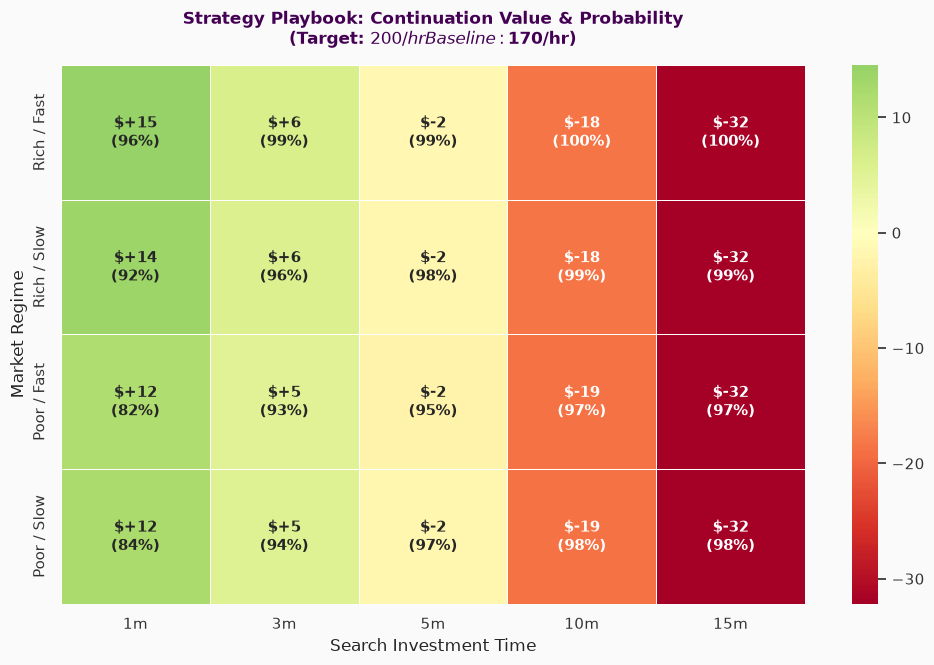

In [26]:
if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 3.4: Generating static CV playbook (target: $200/hr) ---")

    # 1. Data enrichment (secure join)
    df_playbook = df_opportunity_cost.copy()

    # Check if we need to fetch the text description
    if 'reason_primary' not in df_playbook.columns:
        if 'reason_primary_fk' in df_playbook.columns:
            print("Mapping 'reason_primary_fk' to text descriptions...")
            try:
                # Direct query to the dimension table
                q_reasons = "SELECT reason_primary_id, reason_description FROM reason_primary"
                df_reasons = pd.read_sql(q_reasons, db_engine)

                # Merge
                df_playbook = pd.merge(
                    df_playbook,
                    df_reasons,
                    left_on='reason_primary_fk',
                    right_on='reason_primary_id',
                    how='left'
                )

                # Rename for consistency
                df_playbook.rename(columns={'reason_description': 'reason_primary'}, inplace=True)
                print("Mapping successful.")

            except Exception as e:
                print(f"Warning: could not fetch reason descriptions ({e}). Skipping filter.")
                df_playbook['reason_primary'] = 'unknown'  # Placeholder to avoid crash
        else:
            print("Warning: 'reason_primary_fk' not found. Skipping filter.")
            df_playbook['reason_primary'] = 'unknown'

    # 2. Filtering (remove noise)
    # Exclude 'dropoff_non_operational' if the column exists and has data
    if 'reason_primary' in df_playbook.columns:
        initial_len = len(df_playbook)
        # Normalize to string to avoid type errors
        df_playbook['reason_primary'] = df_playbook['reason_primary'].astype(str)

        df_playbook = df_playbook[~df_playbook['reason_primary'].str.contains('dropoff_non_operational', case=False, na=False)].copy()

        dropped_count = initial_len - len(df_playbook)
        if dropped_count > 0:
            print(f"Filtered {dropped_count} 'non-operational' offers (dead zones).")

    # 3. Strategy parameters
    TARGET_EPH = 170.0
    BASELINE_EPH = 150.0  # Standard logic: target - 30

    # 4. Archetype construction (median stats for calculation)
    props_target = df_playbook[
        df_playbook['eph_real'].between(TARGET_EPH - 15, TARGET_EPH + 15)
    ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

    props_base = df_playbook[
        df_playbook['eph_real'].between(BASELINE_EPH - 15, BASELINE_EPH + 15)
    ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

    if props_target.isnull().any() or props_base.isnull().any():
        print(f"Critical: not enough data points near ${BASELINE_EPH} or ${TARGET_EPH} to model CV.")
        print(f"   - Count near ${TARGET_EPH}: {len(df_playbook[df_playbook['eph_real'].between(TARGET_EPH - 15, TARGET_EPH + 15)])}")
        print(f"   - Count near ${BASELINE_EPH}: {len(df_playbook[df_playbook['eph_real'].between(BASELINE_EPH - 15, BASELINE_EPH + 15)])}")

    else:
        # 5. Vectorized oracle (probability calculation)
        df_sim = df_playbook.sort_values('offer_timestamp').copy()
        df_sim['is_success'] = (df_sim['eph_real'] >= TARGET_EPH).astype(int)
        df_sim = df_sim.set_index('offer_timestamp')
        df_reversed = df_sim.iloc[::-1]

        time_windows = {'1m': '60s', '3m': '180s', '5m': '300s', '10m': '600s', '15m': '900s'}

        results = []

        # Immediate baseline value (take the $170 now)
        eph_base_immediate = (props_base['upfront_fare'] /
                             (props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec'])) * 3600

        print(f"   - Baseline immediate EPH: ${eph_base_immediate:.0f}/hr")

        for label, delta_str in time_windows.items():
            delta_sec = int(delta_str[:-1])

            # Roll forward to find success
            found_success = df_reversed['is_success'].rolling(window=delta_str).max().iloc[::-1]

            # Group by quadrant
            probs = found_success.groupby(df_sim['quadrant']).mean()

            for quad, p in probs.items():
                # CV calculation
                # A: success (wait + target trip)
                cycle_success = delta_sec + props_target['time_to_pickup_sec'] + props_target['est_trip_time_sec']
                eph_success_scenario = (props_target['upfront_fare'] / cycle_success) * 3600

                # B: failure (wait + baseline trip)
                cycle_failure = delta_sec + props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec']
                eph_failure_scenario = (props_base['upfront_fare'] / cycle_failure) * 3600

                # Expected EPH of waiting
                ev_wait = (p * eph_success_scenario) + ((1 - p) * eph_failure_scenario)

                # CV (value of waiting vs. taking baseline now)
                cv = ev_wait - eph_base_immediate

                results.append({
                    'Quadrant': quad,
                    'Window': label,
                    'CV': cv,
                    'Prob': p
                })

        # 6. Formatting for heatmap (dual values)
        df_res = pd.DataFrame(results)

        # Create the label matrix (string: "+$45\n(85%)")
        df_res['Label'] = df_res.apply(lambda x: f"${x['CV']:+.0f}\n({x['Prob']:.0%})", axis=1)

        # Pivots
        cv_matrix = df_res.pivot(index='Quadrant', columns='Window', values='CV')
        label_matrix = df_res.pivot(index='Quadrant', columns='Window', values='Label')

        # Ordering
        q_order = ['Rich / Fast', 'Rich / Slow', 'Poor / Fast', 'Poor / Slow']
        cv_matrix = cv_matrix.reindex([q for q in q_order if q in cv_matrix.index])
        label_matrix = label_matrix.reindex([q for q in q_order if q in label_matrix.index])

        cols_order = ['1m', '3m', '5m', '10m', '15m']
        cv_matrix = cv_matrix[cols_order]
        label_matrix = label_matrix[cols_order]

        # 7. Visualization
        plt.figure(figsize=(12, 7))

        # Use CV for color, Label matrix for text
        ax = sns.heatmap(
            cv_matrix,
            annot=label_matrix,
            fmt="",
            cmap="RdYlGn",
            center=0,
            linewidths=.5,
            annot_kws={"size": 11, "weight": "bold"}
        )

        plt.title('Strategy Playbook: Continuation Value & Probability\n(Target: $200/hr  Baseline: $170/hr)',
                  color='#440154', pad=15)
        plt.ylabel('Market Regime')
        plt.xlabel('Search Investment Time')

        plt.show()

else:
    print("Dataframe not found.")


## Phase 4 — Efficient frontier

Generalizes the CV playbook across a full range of target EPH values (160-230), interpolating each quadrant's break-even wait time to draw the efficient frontier of rational search time by ambition.

#### 4.1 — Efficient frontier (rational search time by target EPH)

For each target EPH in the range, computes the CV curve across time windows per quadrant, interpolates the break-even point (where CV crosses zero), and plots the resulting frontier, capped at 9 minutes.

--- 4.1: Generating final frontier (teal/purple, 9m limit) ---


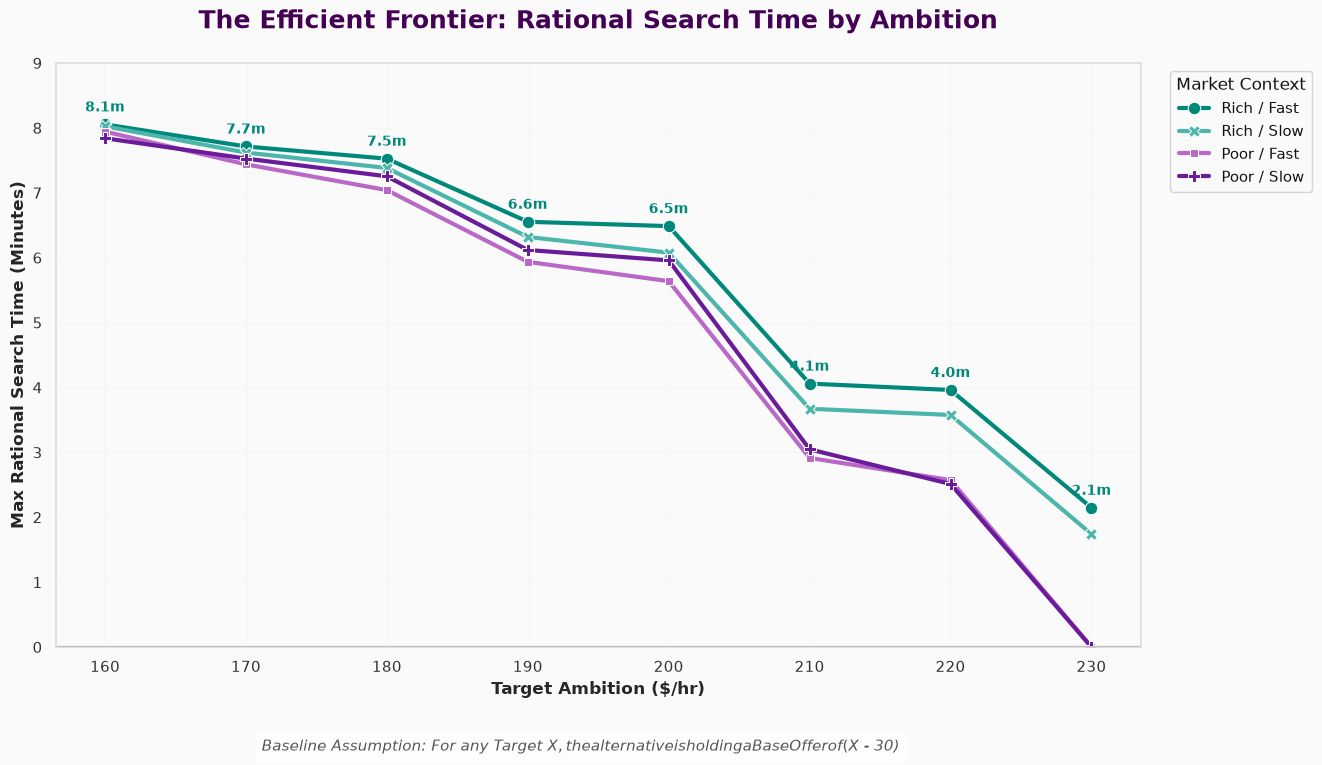

In [27]:
if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 4.1: Generating final frontier (teal/purple, 9m limit) ---")

    # 1. Setup parameters (range 160 to 230)
    target_range = range(160, 240, 10)  # 240 is exclusive, so it stops at 230

    # Time windows map
    windows_min = [1, 3, 5, 10, 15]
    windows_sec = [60, 180, 300, 600, 900]
    windows_map = dict(zip(windows_min, windows_sec))

    frontier_data = []

    # 2. Iterative simulation
    for target_eph in target_range:
        baseline_eph = target_eph - 30

        # Archetypes
        props_base = df_opportunity_cost[
            df_opportunity_cost['eph_real'].between(baseline_eph - 15, baseline_eph + 15)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        props_target = df_opportunity_cost[
            df_opportunity_cost['eph_real'].between(target_eph - 15, target_eph + 15)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        if props_base.isnull().any() or props_target.isnull().any():
            continue

        eph_base_immediate = (props_base['upfront_fare'] /
                              (props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec'])) * 3600

        # Simulation
        df_sim = df_opportunity_cost.sort_values('offer_timestamp').copy()
        df_sim['is_success'] = (df_sim['eph_real'] >= target_eph).astype(int)
        df_sim = df_sim.set_index('offer_timestamp')
        df_reversed = df_sim.iloc[::-1]

        quadrant_cvs = {q: [] for q in ['Rich / Fast', 'Rich / Slow', 'Poor / Fast', 'Poor / Slow']}

        for w_min, w_sec in windows_map.items():
            window_str = f"{w_sec}s"
            found_success = df_reversed['is_success'].rolling(window=window_str).max().iloc[::-1]
            probs = found_success.groupby(df_sim['quadrant']).mean()

            for quad in quadrant_cvs.keys():
                if quad in probs:
                    prob = probs[quad]
                    cycle_success = w_sec + props_target['time_to_pickup_sec'] + props_target['est_trip_time_sec']
                    eph_success = (props_target['upfront_fare'] / cycle_success) * 3600
                    cycle_failure = w_sec + props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec']
                    eph_failure = (props_base['upfront_fare'] / cycle_failure) * 3600

                    ev_wait = (prob * eph_success) + ((1 - prob) * eph_failure)
                    cv = ev_wait - eph_base_immediate
                    quadrant_cvs[quad].append(cv)
                else:
                    quadrant_cvs[quad].append(np.nan)

        # Interpolation
        for quad, cvs in quadrant_cvs.items():
            valid_indices = [i for i, v in enumerate(cvs) if not np.isnan(v)]
            if len(valid_indices) < 2:
                continue

            x_vals = [windows_min[i] for i in valid_indices]
            y_vals = [cvs[i] for i in valid_indices]

            if y_vals[0] < 0:
                break_even_time = 0
            elif all(y > 0 for y in y_vals):
                break_even_time = 15.2
            else:
                f = interp1d(y_vals, x_vals, kind='linear', fill_value="extrapolate")
                break_even_time = float(f(0))
                break_even_time = max(0, min(break_even_time, 15.5))

            frontier_data.append({
                'Target EPH': target_eph,
                'Quadrant': quad,
                'Max Wait Time (Minutes)': break_even_time
            })

    # 3. Visualization
    df_frontier = pd.DataFrame(frontier_data)

    plt.figure(figsize=(14, 8))

    # Custom palette: teal (good) -> purple (bad)
    teal_purple_palette = {
        'Rich / Fast': '#00897B',  # Strong teal (best case)
        'Rich / Slow': '#4DB6AC',  # Soft teal
        'Poor / Fast': '#BA68C8',  # Soft purple
        'Poor / Slow': '#6A1B9A'   # Deep purple (worst case)
    }

    ax = sns.lineplot(
        data=df_frontier,
        x='Target EPH',
        y='Max Wait Time (Minutes)',
        hue='Quadrant',
        palette=teal_purple_palette,
        style='Quadrant',
        markers=True,
        dashes=False,
        linewidth=3,
        markersize=9
    )

    # 4. Aesthetics & limits
    plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
    plt.ylim(0, 9)  # Capped at 9 minutes as requested

    # 5. Labels (Rich/Fast only)
    rich_fast_points = df_frontier[df_frontier['Quadrant'] == 'Rich / Fast']

    for idx, row in rich_fast_points.iterrows():
        plt.text(
            x=row['Target EPH'],
            y=row['Max Wait Time (Minutes)'] + 0.2,  # Slight offset upwards
            s=f"{row['Max Wait Time (Minutes)']:.1f}m",
            color=teal_purple_palette['Rich / Fast'],
            fontsize=10,
            fontweight='bold',
            ha='center'
        )

    # 6. Titles & legends
    plt.title('The Efficient Frontier: Rational Search Time by Ambition',
              fontsize=18, fontweight='bold', color='#440154', pad=25)

    plt.figtext(0.5, 0.02,
                "Baseline Assumption: For any Target $X, the alternative is holding a Base Offer of ($X - 30)",
                ha="center", fontsize=11, style='italic', color='#555555',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))

    plt.xlabel('Target Ambition ($/hr)', fontsize=12, fontweight='bold')
    plt.ylabel('Max Rational Search Time (Minutes)', fontsize=12, fontweight='bold')
    plt.xticks(target_range)
    plt.grid(True, alpha=0.15)

    plt.legend(title='Market Context', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

    plt.subplots_adjust(bottom=0.15)

    plt.show()

else:
    print("Run previous cells to load data first.")


## Phase 5 — Supply elasticity

Does the driver's actual acceptance behavior track offer quality? A supply-curve check: acceptance rate against the normalized offer quality index.

#### 5.1 — Agent supply curve (behavioral response)

Bins offers into quality deciles and plots the acceptance rate against quality, as a behavioral validation of the quality index itself.

--- 5.1: Analyzing behavioral supply elasticity (zoomed) ---


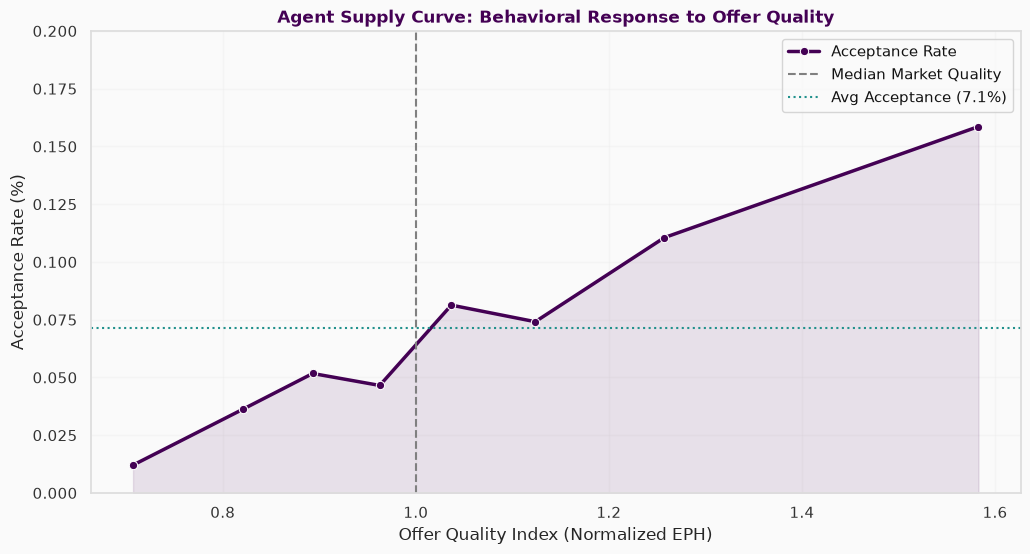

,quality_bin,avg_quality_index,acceptance_rate,offer_count,elasticity
0,0,0.71,1.2%,580,nan
1,1,0.82,3.6%,579,12.44
2,2,0.89,5.2%,580,4.84
3,3,0.96,4.7%,580,-1.29
4,4,1.04,8.1%,578,9.69
5,5,1.12,7.4%,580,-1.05
6,6,1.26,11.1%,579,4.13
7,7,1.58,15.9%,580,1.68


In [28]:
if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 5.1: Analyzing behavioral supply elasticity (zoomed) ---")

    # 1. Inspect the data
    actual_actions = df_opportunity_cost['offer_action'].unique()

    df_el = df_opportunity_cost.copy()

    # 2. Robust acceptance identification
    df_el['was_accepted'] = df_el['offer_action'].astype(str).str.upper().str.contains('ACCEPT').astype(int)

    # 3. Create quality deciles (8 bins)
    df_el['quality_bin'] = pd.qcut(df_el['offer_quality_index'], 8, labels=False, duplicates='drop')

    # 4. Compute the supply curve
    supply_curve = df_el.groupby('quality_bin').agg(
        avg_quality_index=('offer_quality_index', 'mean'),
        acceptance_rate=('was_accepted', 'mean'),
        offer_count=('offer_id', 'count')
    ).reset_index()

    # 5. Compute elasticity
    supply_curve['elasticity'] = (supply_curve['acceptance_rate'].pct_change() /
                                  supply_curve['avg_quality_index'].pct_change())

    # 6. Visualization
    plt.figure(figsize=(12, 6))

    # Main supply curve
    sns.lineplot(x='avg_quality_index', y='acceptance_rate', data=supply_curve,
                 marker='o', color=PIENZA_PURPLE, linewidth=2.5, label='Acceptance Rate')

    # Fill under the curve
    plt.fill_between(supply_curve['avg_quality_index'], supply_curve['acceptance_rate'],
                     color=PIENZA_PURPLE, alpha=0.1)

    # Threshold markers
    plt.axvline(1.0, color='gray', linestyle='--', label='Median Market Quality')
    plt.axhline(df_el['was_accepted'].mean(), color=PIENZA_TEAL, linestyle=':',
                label=f'Avg Acceptance ({df_el["was_accepted"].mean():.1%})')

    plt.title('Agent Supply Curve: Behavioral Response to Offer Quality', color=PIENZA_PURPLE)
    plt.xlabel('Offer Quality Index (Normalized EPH)')
    plt.ylabel('Acceptance Rate (%)')

    plt.ylim(0, 0.20)

    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    display(supply_curve.style.format({
        'avg_quality_index': '{:.2f}',
        'acceptance_rate': '{:.1%}',
        'elasticity': '{:.2f}'
    }))

else:
    print("Error: df_opportunity_cost not loaded.")


---

## Appendix — variable journey

```mermaid
flowchart TD
    dossier["pienza.db: offers + sessions"] --> df_opp["df_opportunity_cost\n(unified ingest, central dataframe)"]
    df_opp --> df_deltas["df_deltas_valid\n(inter-offer delta, session rhythm)"]

    df_opp --> escape["Baseline escape clock\n(EPH 150 vs 200 indifference point)"]
    df_opp --> df_prob["df_prob\n(sorted by time, success probabilities)"]
    df_prob --> matrix["Strategic probability matrix"]
    df_opp --> simulator["Continuation value simulator\n(interactive, target EPH)"]

    escape --> frontier["Efficient frontier\n(rational search time by target EPH)"]
    df_opp --> df_el["df_el\n(behavioral supply elasticity)"]
    df_el --> supply["Agent supply curve"]

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```